# **GPA Change Analysis**

write the outlook of the project.

# Introduction:
These days AI is growing fast and we can say it's a most used tool on our daily tasks. Huge improvements of the field and the genesis of chatbots caused by the improvements and fundings we can see some useful AI tools like ChatGPT, Claude, etc. These tools changed our lifes and make task and learning different. It was my own problem with the AI that what are the conciquencies of using AI? Does AI have negative effects on our long-term memory and our IQ level? Not using AI will results in low progression among high level and efficient people that we wanna compete and I'm not sure using AI a lot results in good things for our brain so I try to answer some of the questions using this analysis and I hope the results and conclusions make us to decide better on using AI in which way and for how many hours.

This dataset has some useful features and lots of samples that helps us on our way to make data-driven decisions abour AI usage in our lifes.


dataset source: https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students

# Problem Definition:
**How does AI usage correlated with academic improvement or declined?**

This is the main question we're trying to find solution for and we're going to define a regression task for it. We're going to train and built a regression model on this dataset to predict the GPA change of the students based-on the features related to their academic profile, AI behaviour, study habits, institutional policies, and well-being.

📁 **AI_Student_Impact_Dataset**:

🪪 `Identifier:` Student_ID

🎓 `Academic Profile:` Major_Category, Year_of_Study, Pre/Post GPA

🤖 `AI Behaviour:` Weekly_GenAI_Hours, Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity, Paid_Subscription

📚 `Study Habits:` Traditional_Study_Hours, Perceived_AI_Dependency

🏛️ `Institutional:` Institutional_Policy

🧠 `Well-being:` Anxiety_Level, Skill_Retention_Score, Burnout_Risk_Level

In [118]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import preprocessing as pr

print("Importations Successful.")

Importations Successful.


In [119]:
# versions of the used third-party packages
from sklearn import __version__ as sklearn_version
from numpy import __version__ as np_version
from pandas import __version__ as pd_version
from seaborn import __version__ as sns_version
from matplotlib import __version__ as plt_version

print(f"Scikit-learn's Version: {sklearn_version}")
print(f"NumPy's Version: {np_version}")
print(f"Pandas's Version: {pd_version}")
print(f"Seaborn's Version: {sns_version}")
print(f"Matploblib's Version: {plt_version}")

Scikit-learn's Version: 1.8.0
NumPy's Version: 2.4.2
Pandas's Version: 3.0.0
Seaborn's Version: 0.13.2
Matploblib's Version: 3.10.8


In [120]:
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.1
)

## 1. Data Structure and Types Examinations

In [121]:
df = pd.read_csv("/mnt/d/Pytopia/Machine Learning/Applied-ML-Lab/core_ml/regression/impact_of_ai_on_students/data/ai_student_impact_dataset (1).csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [122]:
df.shape

(50000, 16)

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [124]:
pr.describe(df)

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.250005e+05,3.146102,8.427752,2.800260,11.209271,3.505360,4.270760,3.349299,75.798125
median,1.250005e+05,3.210000,5.800000,3.000000,11.180000,3.000000,4.000000,3.421000,76.000000
std,1.443390e+04,0.478854,8.269490,1.188020,5.156426,1.820812,2.144066,0.495673,13.281626
variance,2.083375e+08,0.229301,68.384460,1.411392,26.588730,3.315358,4.597021,0.245691,176.401597
min,1.000010e+05,1.183000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,1.125008e+05,2.834000,2.390000,2.000000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,1.250005e+05,3.210000,5.800000,3.000000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,1.375002e+05,3.521000,11.720000,4.000000,14.710000,5.000000,6.000000,3.749000,85.190000
max,1.500000e+05,3.998000,40.000000,5.000000,35.860000,10.000000,10.000000,4.000000,100.000000


In [125]:
df['Student_ID'].nunique() == 50_000

True

In [126]:
# fixing datatypes for categorical variables
df['Major_Category'] = df['Major_Category'].str.lower().astype("category")
df['Year_of_Study'] = df['Year_of_Study'].str.lower().astype("category")
df['Primary_Use_Case'] = df['Primary_Use_Case'].str.lower().astype("category")
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].str.lower().astype("category")
df['Institutional_Policy'] = df['Institutional_Policy'].str.lower().astype("category")
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].str.lower().astype("category")

In [127]:
print("percentage of each category in `Major_Category`:")
df['Major_Category'].value_counts() / df.shape[0] * 100

percentage of each category in `Major_Category`:


Major_Category
stem          30.118
business      25.076
humanities    19.988
medical       12.952
arts          11.866
Name: count, dtype: float64

In [128]:
pr.category_percentage(df['Major_Category'])

,Major_Category,percent
0,stem,% 30.12
1,business,% 25.08
2,humanities,% 19.99
3,medical,% 12.95
4,arts,% 11.87


In [129]:
pr.category_percentage(df['Year_of_Study'])

,Year_of_Study,percent
0,junior,% 22.09
1,freshman,% 22.06
2,senior,% 21.27
3,sophomore,% 19.72
4,graduate,% 14.86


/tmp/ipykernel_39775/928278326.py:34: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


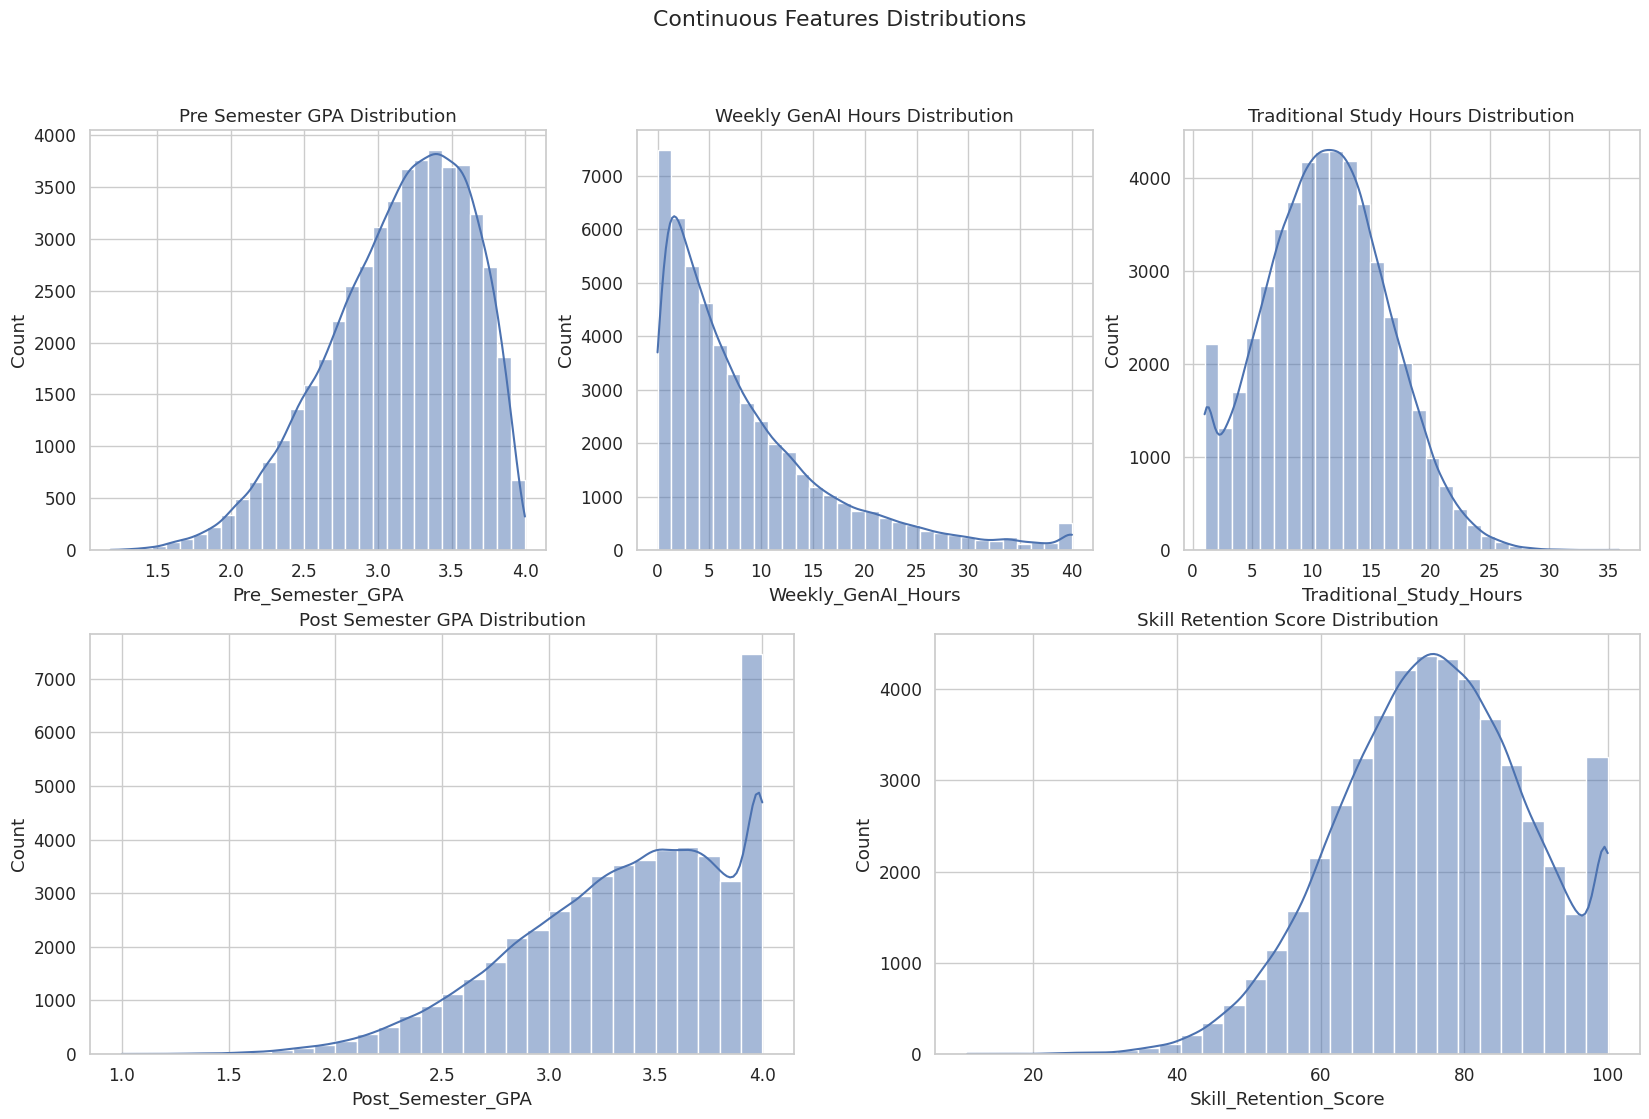

In [130]:
fig = plt.figure(figsize=(20, 12))
plt.suptitle("Continuous Features Distributions")

ax1 = plt.subplot(231)
sns.histplot(data=df, x="Pre_Semester_GPA", kde=True, bins=30, ax=ax1)
ax1.set(
    title="Pre Semester GPA Distribution"
)

ax2 = plt.subplot(232)
sns.histplot(data=df, x="Weekly_GenAI_Hours", kde=True, bins=30, ax=ax2)
ax2.set(
    title="Weekly GenAI Hours Distribution"
)

ax3 = plt.subplot(233)
sns.histplot(data=df, x="Traditional_Study_Hours", kde=True, bins=30, ax=ax3)
ax3.set(
    title="Traditional Study Hours Distribution"
)

ax4 = plt.subplot(223)
sns.histplot(data=df, x="Post_Semester_GPA", kde=True, bins=30, ax=ax4)
ax4.set(
    title="Post Semester GPA Distribution"
)

ax5 = plt.subplot(224)
sns.histplot(data=df, x="Skill_Retention_Score", kde=True, bins=30, ax=ax5)
ax5.set(
    title="Skill Retention Score Distribution"
)

plt.tight_layout()

by looking at the distribution of the weekly GenAI hours we can say maybe a log transformation on this feature makes it more like normal distribution and may results in a better feature.

In [131]:
pr.category_percentage(df['Primary_Use_Case'])

,Primary_Use_Case,percent
0,debugging/troubleshooting,% 24.59
1,copywriting/drafting,% 24.02
2,ideation,% 21.44
3,summarizing_reading,% 17.27
4,direct_answer_generation,% 12.68


In [132]:
pr.category_percentage(df['Prompt_Engineering_Skill'])

,Prompt_Engineering_Skill,percent
0,beginner,% 36.99
1,intermediate,% 35.39
2,advanced,% 27.62


In [133]:
pr.category_percentage(df['Tool_Diversity'])

,Tool_Diversity,percent
0,3,% 33.85
1,2,% 23.66
2,1,% 16.28
3,4,% 16.16
4,5,% 10.04


In [134]:
pr.category_percentage(df["Paid_Subscription"])

,Paid_Subscription,percent
0,False,% 57.69
1,True,% 42.31


We can see most of the students do not pay for the AI subscription and it can have this meaning that the number of students who are the professional user of the AI are less than the students who use AI a little not for high level tasks also cause doing high-level tasks and using AI regularly needs many tokens usage so they must by the subscription to do this.

In [162]:
pr.category_percentage(df['Perceived_AI_Dependency'])

,Perceived_AI_Dependency,percent
0,3,% 20.96
1,4,% 19.87
2,2,% 17.75
3,1,% 14.61
4,5,% 13.49
5,6,% 7.04
6,7,% 3.44
7,8,% 1.71
8,9,% 0.76
9,10,% 0.38


we can see that not many students are much dependent on the AI and can handle their tasks in traditional ways.

In [177]:
students_with_high_ai_dependency_percent = pr.category_percentage(
    df['Perceived_AI_Dependency']).iloc[5:, 1].str.replace("%", "").astype(float).sum()

print(f"Percentage of students with High AI dependency: %{students_with_high_ai_dependency_percent: .2f}")

Percentage of students with High AI dependency: % 13.33


In [179]:
pr.category_percentage(df['Institutional_Policy'])

,Institutional_Policy,percent
0,allowed_with_citation,% 50.45
1,actively_encouraged,% 29.98
2,strict_ban,% 19.58


In [181]:
pr.category_percentage(df['Anxiety_Level_During_Exams'])

,Anxiety_Level_During_Exams,percent
0,4,% 17.50
1,5,% 16.44
2,3,% 15.61
3,6,% 12.21
4,2,% 11.50
5,1,% 11.31
6,7,% 7.70
7,8,% 4.18
8,9,% 2.30
9,10,% 1.24


In [214]:
pr.category_percentage(df['Burnout_Risk_Level'])

,Burnout_Risk_Level,percent
0,medium,% 42.29
1,low,% 32.74
2,high,% 24.97


In [220]:
df.groupby("Major_Category")['Weekly_GenAI_Hours'].mean()

Major_Category
arts           7.271702
business       8.275898
humanities     6.770144
medical        7.546728
stem          10.488609
Name: Weekly_GenAI_Hours, dtype: float64

In [227]:
print("Weekly GenAI hours by major category:")
df.pivot_table(
    values="Weekly_GenAI_Hours",
    index="Major_Category",
    columns="Year_of_Study",
).mean(axis=1)

Weekly GenAI hours by major category:


Major_Category
arts           7.277241
business       8.280224
humanities     6.779554
medical        7.558905
stem          10.467515
dtype: float64

STEM major category students average usage of the AI is much more than other major categories.

In [238]:
year_of_study_sorted = ["freshman", "sophomore", "junior", "senior", "graduate"]
df.pivot_table(
    values="Traditional_Study_Hours",
    index="Major_Category",
    columns="Year_of_Study",
).loc[:, year_of_study_sorted].mean(axis=1)

Major_Category
arts          11.369427
business      11.203602
humanities    11.320793
medical       11.369779
stem          11.005075
dtype: float64

students have from different majors almost have the same study hours.

In [243]:
df.pivot_table(
    values="Skill_Retention_Score",
    index="Major_Category",
    columns="Year_of_Study",
).mean(axis=1)

Major_Category
arts          75.756203
business      75.395248
humanities    75.348286
medical       75.605528
stem          76.876486
dtype: float64

We can see that the higher AI hours usage does not result in lower skill retention for STEM major category students in general.

In [265]:
print("Primary usage of each major category:")
df.pivot_table(
    values="Weekly_GenAI_Hours",
    index="Major_Category",
    columns="Primary_Use_Case",
).style.highlight_max(axis=1, props="background-color: green; color: black")

Primary usage of each major category:


Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,7.079039,7.600061,7.286136,7.669858,7.133167
business,8.086853,8.455982,8.397550,8.325226,7.977930
humanities,6.876253,6.375336,6.599464,6.742134,6.879968
medical,7.184280,7.591809,7.315104,7.673786,7.657968
stem,10.352187,10.445044,10.689452,10.479799,10.615806


In [277]:
df.pivot_table(
    values="Traditional_Study_Hours",
    index="Major_Category",
    columns="Primary_Use_Case",
)

Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,11.480311,11.176175,11.373050,10.875905,11.586916
business,11.115821,11.192232,11.207738,11.212835,11.274560
humanities,11.460557,11.175448,11.375610,11.154005,11.121037
medical,11.185907,11.536155,11.313291,11.301839,11.394329
stem,10.884931,11.050112,11.014767,10.947872,10.975083


In [276]:
df.pivot_table(
    values="Post_Semester_GPA",
    index="Major_Category",
    columns="Primary_Use_Case",
)

Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,3.335106,3.412374,3.280752,3.375924,3.332401
business,3.325177,3.394387,3.263723,3.342111,3.339186
humanities,3.340246,3.332432,3.356198,3.351537,3.366199
medical,3.346966,3.395354,3.315878,3.360430,3.351273
stem,3.325311,3.403913,3.279012,3.320544,3.354301


We can see a pattern that STEM major category students that their primary use case of using AI are copywriting/drafting or ideation, spent less time on studying in traditional ways but the average GPA of them is very similar to others but students in this major category whos primary use case was getting direct answers from the AI do worse than others in this major category by GPA score.

STEM major category students are a little AI dependent in average.

In [283]:
df.pivot_table(
    values="Skill_Retention_Score",
    index="Major_Category",
    columns="Primary_Use_Case",
).style.highlight_min(axis=1, props="background-color: red; color: white").highlight_max(
        axis=1, props="background-color: green; color: black"
	)

Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,75.580484,77.951072,74.633925,74.846402,75.497983
business,74.546163,76.938372,73.625743,75.500935,75.011123
humanities,75.110279,77.196420,74.148955,75.647890,74.657584
medical,74.707735,77.231092,73.925901,75.861707,75.523845
stem,75.912964,78.543921,73.037907,75.655056,75.172458


## 2. Handling Missing Values & De-Duplication Task:

This dataset is a ready-to-use dataset and there is no missing values or duplicates in it by the publisher's note. just to make sure:

In [188]:
# number of missing values
df.isnull().sum().sum()

np.int64(0)

In [192]:
# number of the duplicated samples
df.duplicated().sum()

np.int64(0)

## 3. Handling Data Irregularities: (Hold for now)

In [197]:
numeric_features = []
for column in df.columns:
    if df[column].dtype not in ["category", "bool"]:
        numeric_features.append(column)

numeric_features

['Student_ID',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [210]:
potential_outliers = {}
for i in range(len(numeric_features)):
	potential_outliers[numeric_features[i]] = pr.detect_potential_outliers(df, numeric_features[i])

potential_outliers

{'Student_ID': RangeIndex(start=0, stop=0, step=1),
 'Pre_Semester_GPA': Index([   31,   198,   443,   671,   853,  1212,  1738,  1835,  2401,  2561,
        ...
        47997, 48302, 48331, 48394, 48443, 48773, 48943, 49426, 49580, 49662],
       dtype='int64', length=197),
 'Weekly_GenAI_Hours': Index([   89,   124,   148,   149,   184,   304,   319,   333,   363,   380,
        ...
        49669, 49693, 49777, 49785, 49821, 49828, 49850, 49877, 49908, 49937],
       dtype='int64', length=1144),
 'Tool_Diversity': RangeIndex(start=0, stop=0, step=1),
 'Traditional_Study_Hours': Index([ 1056,  1461,  1854,  2080,  4444,  4465,  4592,  4709,  5400,  6120,
         7668,  8047, 10074, 10520, 12235, 12298, 12748, 13489, 14014, 15603,
        16048, 16272, 17095, 18166, 18446, 19500, 20110, 20267, 20932, 22719,
        22862, 24408, 25568, 25580, 26271, 26394, 26872, 26891, 27307, 28615,
        28796, 30291, 30377, 30426, 30428, 30522, 31162, 31477, 31769, 32804,
        33086, 33101, 33

<Axes: xlabel='Pre_Semester_GPA', ylabel='Count'>

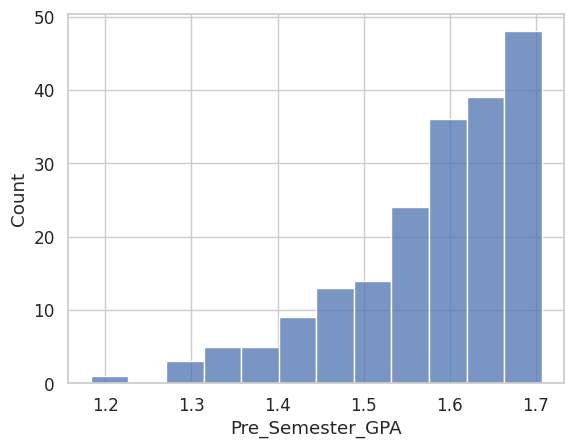

In [213]:
sns.histplot(df.loc[potential_outliers['Pre_Semester_GPA'], "Pre_Semester_GPA"])

## 4. Feature Engineering:

brain storming:
- GPA change
- 